<a href="https://colab.research.google.com/github/ayismi07/Simulation-Reservoir-Changes-Using-Machine-Leaning-CCS-Technology-/blob/main/Project_Machine_Learning_(Skripsi).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pymc

In [ ]:
pip install lasio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lasio
import lasio.examples

In [ ]:
las = lasio.read('/content/synthetic_well_log_full.las')
well = las.df()


In [ ]:
well = well.drop(columns=['SW', 'VSH'])

In [ ]:
well = well.dropna()
well

,GR,CALI,BS,RHOB,NPHI,PEF,DT,DTS,RESD,RESM,RESS,SP,DRHO,PHIT,PERM,ROP,TEMP
DEPT,,,,,,,,,,,,,,,,,
5004.0,115.25,8.35,8.50,2.4186,0.3599,3.31,99.75,175.53,1.878,1.552,1.225,-0.20,0.00,0.2501,0.0,8.19,75.12
5004.5,119.61,8.53,8.50,2.4710,0.3514,3.62,96.08,166.35,3.622,2.992,2.362,-0.04,0.02,0.2300,0.0,23.57,75.13
5005.0,103.69,8.70,8.50,2.4955,0.3526,3.17,93.74,165.04,2.105,1.739,1.373,-0.67,0.01,0.2231,0.0,32.22,75.31
5005.5,104.96,8.36,8.50,2.4011,0.3486,3.33,96.72,175.53,3.773,3.117,2.461,1.11,0.02,0.2497,0.0,25.81,75.05
5006.0,116.62,8.66,8.50,2.4070,0.3594,3.39,98.76,179.81,2.824,2.333,1.842,4.63,0.01,0.2533,0.0,30.98,75.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347.5,58.45,8.39,6.12,2.5457,0.0463,3.25,65.81,116.39,44.691,36.919,29.147,1.59,0.03,0.0547,0.0,37.52,109.91
7348.0,53.54,8.76,6.12,2.5648,0.0471,3.15,67.67,114.82,49.943,41.257,32.572,2.57,-0.01,0.0494,0.0,36.97,110.08
7348.5,50.34,8.28,6.12,2.5655,0.0627,3.30,63.01,114.03,46.144,38.119,30.094,3.59,-0.04,0.0569,0.0,34.87,110.61


In [ ]:
np.shape(well)

(4236, 17)

In [ ]:
well['DEPTH'] = well.index
print(well.head())

            GR  CALI   BS    RHOB    NPHI   PEF     DT     DTS   RESD   RESM  \
DEPT                                                                           
5004.0  115.25  8.35  8.5  2.4186  0.3599  3.31  99.75  175.53  1.878  1.552   
5004.5  119.61  8.53  8.5  2.4710  0.3514  3.62  96.08  166.35  3.622  2.992   
5005.0  103.69  8.70  8.5  2.4955  0.3526  3.17  93.74  165.04  2.105  1.739   
5005.5  104.96  8.36  8.5  2.4011  0.3486  3.33  96.72  175.53  3.773  3.117   
5006.0  116.62  8.66  8.5  2.4070  0.3594  3.39  98.76  179.81  2.824  2.333   

         RESS    SP  DRHO    PHIT  PERM    ROP   TEMP   DEPTH  
DEPT                                                           
5004.0  1.225 -0.20  0.00  0.2501   0.0   8.19  75.12  5004.0  
5004.5  2.362 -0.04  0.02  0.2300   0.0  23.57  75.13  5004.5  
5005.0  1.373 -0.67  0.01  0.2231   0.0  32.22  75.31  5005.0  
5005.5  2.461  1.11  0.02  0.2497   0.0  25.81  75.05  5005.5  
5006.0  1.842  4.63  0.01  0.2533   0.0  30.98  75.79  

In [ ]:
well.rename(columns={'DEPT' : 'DEPTH'}, inplace=True)
print(well.head())

            GR  CALI   BS    RHOB    NPHI   PEF     DT     DTS   RESD   RESM  \
DEPT                                                                           
5004.0  115.25  8.35  8.5  2.4186  0.3599  3.31  99.75  175.53  1.878  1.552   
5004.5  119.61  8.53  8.5  2.4710  0.3514  3.62  96.08  166.35  3.622  2.992   
5005.0  103.69  8.70  8.5  2.4955  0.3526  3.17  93.74  165.04  2.105  1.739   
5005.5  104.96  8.36  8.5  2.4011  0.3486  3.33  96.72  175.53  3.773  3.117   
5006.0  116.62  8.66  8.5  2.4070  0.3594  3.39  98.76  179.81  2.824  2.333   

         RESS    SP  DRHO    PHIT  PERM    ROP   TEMP   DEPTH  
DEPT                                                           
5004.0  1.225 -0.20  0.00  0.2501   0.0   8.19  75.12  5004.0  
5004.5  2.362 -0.04  0.02  0.2300   0.0  23.57  75.13  5004.5  
5005.0  1.373 -0.67  0.01  0.2231   0.0  32.22  75.31  5005.0  
5005.5  2.461  1.11  0.02  0.2497   0.0  25.81  75.05  5005.5  
5006.0  1.842  4.63  0.01  0.2533   0.0  30.98  75.79  

Text(0.5, 0, 'Amplitude')

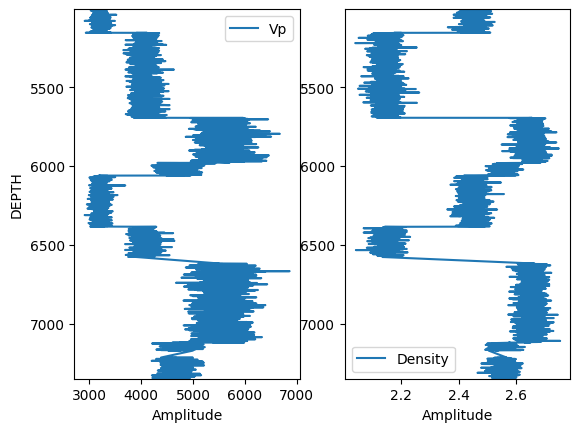

In [ ]:
DT = well['DT']
density = well['RHOB']
d = well['DEPTH']
vp = 0.3048 / (DT * 1e-6)

plt.subplot(1, 2, 1)
plt.plot(vp, d, label='Vp')
plt.ylim([max(d), min(d)])
plt.legend()
plt.xlabel('Amplitude')
plt.ylabel('DEPTH')

plt.subplot(1, 2, 2)
plt.plot(density, d, label='Density')
plt.ylim([max(d), min(d)])
plt.legend()
plt.xlabel('Amplitude')
# plt.ylabel('DEPTH')

In [ ]:
density2 = np.asarray(density)
vp2 = np.asarray(vp)

In [ ]:
true_noise = 0.02

rng = np.random.default_rng(123)
density2_noisy = density2 + rng.normal(0, true_noise, size=len(density2))
vp2_noisy = vp2 + rng.normal(0, true_noise, size=len(vp2))

In [ ]:
with pm.Model() as model_:
    noises = pm.HalfNormal('noises', sigma=0.025)
    yh_ = density2
    yo_ = pm.Normal('yo_', mu=yh_, sigma=noises,
                     observed=density2_noisy)
    trace_ = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True, random_seed=42)
    ppc = pm.sample_posterior_predictive(trace_, random_seed=42)

Output()

Output()

array([[<Axes: title={'center': 'noises'}>,
        <Axes: title={'center': 'noises'}>]], dtype=object)

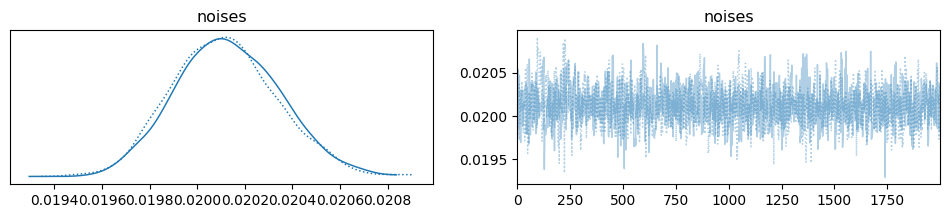

In [ ]:
pm.plot_trace(trace_)

<Axes: title={'center': 'noises'}>

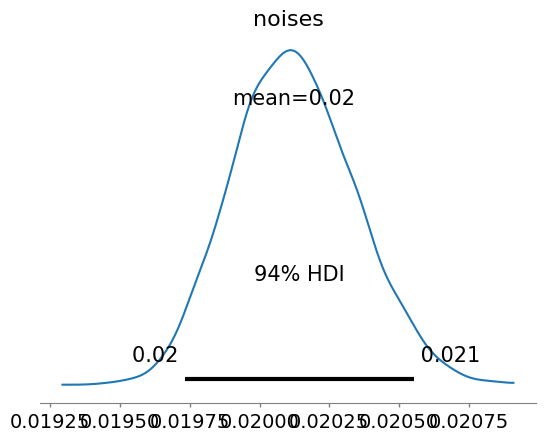

In [ ]:
pm.plot_posterior(trace_)

In [ ]:
yo_pred = ppc.posterior_predictive['yo_']
yo_pred_flat = yo_pred.values.reshape(-1, yo_pred.shape[-1])

N_SAMPLES_PLOT = 200
rng_plot = np.random.default_rng(0)
sample_idx = rng_plot.choice(yo_pred_flat.shape[0],
                              size=min(N_SAMPLES_PLOT, yo_pred_flat.shape[0]),
                              replace=False)

Text(0.5, 1.0, 'bayesian mcmc density log')

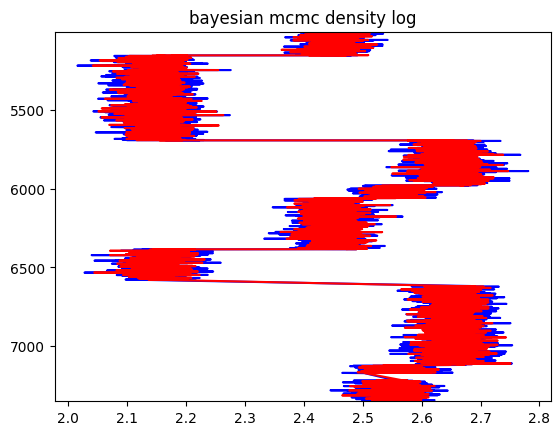

In [ ]:
plt.plot(density2_noisy, d, '-b')
# plt.title('density log')
# plt.subplot(122)
plt.plot(density2, d, '-r')
plt.ylim([max(d), min(d)])
plt.title('bayesian mcmc density log')

In [ ]:
pred_mean = yo_pred_flat.mean(axis=0)
pred_std = yo_pred_flat.std(axis=0)

print(f"\nRata-rata lebar sebaran (std posterior predictive): {pred_std.mean():.4f}")
print(f"Rata-rata selisih |prediksi - asli|                : "
      f"{np.mean(np.abs(pred_mean - density2)):.4f}")


Rata-rata lebar sebaran (std posterior predictive): 0.0201
Rata-rata selisih |prediksi - asli|                : 0.0003


In [ ]:
from scipy import stats

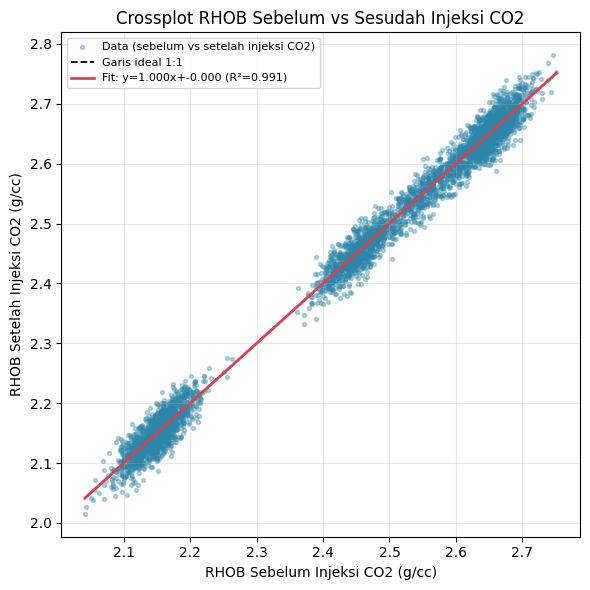

In [ ]:
result = stats.linregress(density2, density2_noisy)
slope, intercept, r_value, p_value, std_err = result
r_squared = r_value ** 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(density2, density2_noisy, s=8, alpha=0.35, color="#2E86AB",
           label="Data (sebelum vs setelah injeksi CO2)")

x_line = np.linspace(density2.min(), density2.max(), 100)
ax.plot(x_line, x_line, "k--", lw=1.3, label="Garis ideal 1:1")
ax.plot(x_line, slope * x_line + intercept, color="#D64550", lw=2,
        label=f"Fit: y={slope:.3f}x+{intercept:.3f} (R²={r_squared:.3f})")

ax.set_xlabel("RHOB Sebelum Injeksi CO2 (g/cc)")
ax.set_ylabel("RHOB Setelah Injeksi CO2 (g/cc)")
ax.set_title("Crossplot RHOB Sebelum vs Sesudah Injeksi CO2")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as model_:
    noises1 = pm.HalfNormal('noises', sigma=0.54)
    yh1_ = vp2
    yo1_ = pm.Normal('yo_', mu=yh1_, sigma=noises1,
                     observed=vp2_noisy)
    trace1_ = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True, random_seed=42)
    ppc1 = pm.sample_posterior_predictive(trace1_, random_seed=42)

Output()

Output()

array([[<Axes: title={'center': 'noises'}>,
        <Axes: title={'center': 'noises'}>]], dtype=object)

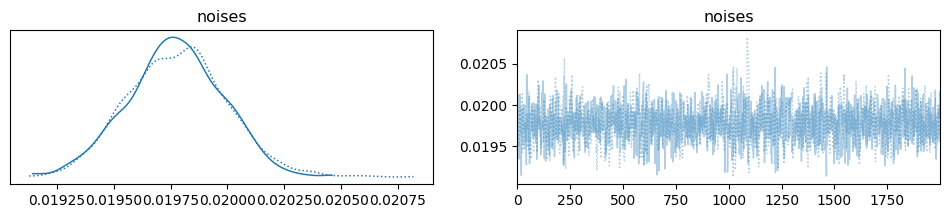

In [ ]:
pm.plot_trace(trace1_)

<Axes: title={'center': 'noises'}>

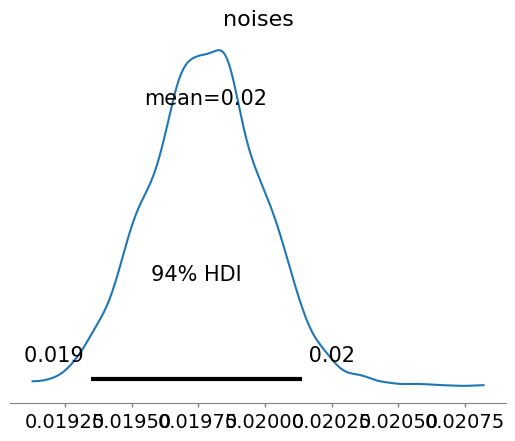

In [ ]:
pm.plot_posterior(trace1_)

In [ ]:
yo_pred1 = ppc1.posterior_predictive['yo_']
yo_pred_flat1 = yo_pred1.values.reshape(-1, yo_pred1.shape[-1])

N_SAMPLES_PLOT = 200
rng_plot1 = np.random.default_rng(0)
sample_idx1 = rng_plot1.choice(yo_pred_flat.shape[0],
                              size=min(N_SAMPLES_PLOT, yo_pred_flat.shape[0]),
                              replace=False)

Text(0.5, 1.0, 'bayesian mcmc velocity log')

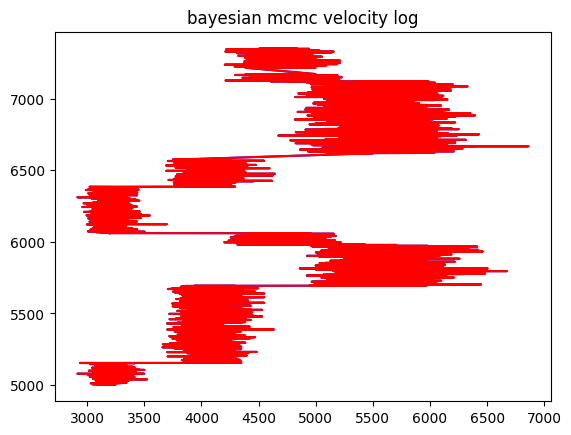

In [ ]:
# plt.subplot(121)
plt.plot(vp2_noisy, d, '-b')
# plt.title('density log')
# plt.subplot(122)
plt.plot(vp2, d, '-r')
plt.title('bayesian mcmc velocity log')

In [ ]:
pred_mean1 = yo_pred_flat1.mean(axis=0)
pred_std1 = yo_pred_flat1.std(axis=0)

print(f"\nRata-rata lebar sebaran (std posterior predictive): {pred_std1.mean():.4f}")
print(f"Rata-rata selisih |prediksi - asli|                : "
      f"{np.mean(np.abs(pred_mean1 - vp2)):.4f}")


Rata-rata lebar sebaran (std posterior predictive): 0.0198
Rata-rata selisih |prediksi - asli|                : 0.0003


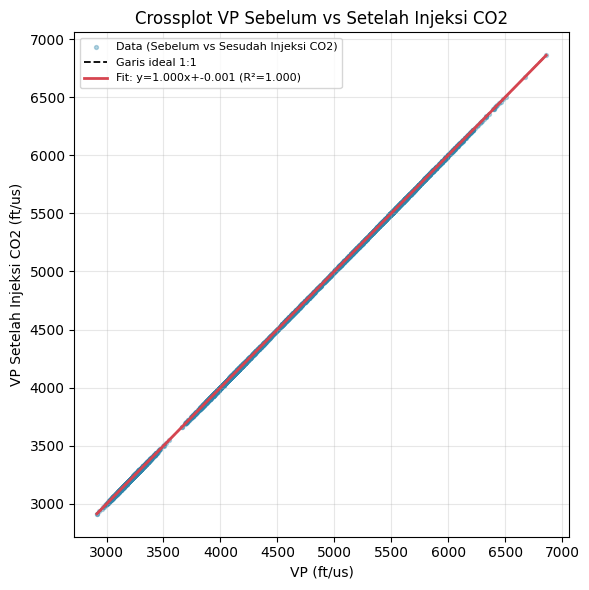

In [ ]:
result1 = stats.linregress(vp2, vp2_noisy)
slope1, intercept1, r_value1, p_value1, std_err1 = result1
r_squared1 = r_value1 ** 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(vp2, vp2_noisy, s=8, alpha=0.35, color="#2E86AB",
           label="Data (Sebelum vs Sesudah Injeksi CO2)")

x_line1 = np.linspace(vp2.min(), vp2.max(), 100)
ax.plot(x_line1, x_line1, "k--", lw=1.3, label="Garis ideal 1:1")
ax.plot(x_line1, slope1 * x_line1 + intercept1, color="#D64550", lw=2,
        label=f"Fit: y={slope1:.3f}x+{intercept1:.3f} (R²={r_squared1:.3f})")

ax.set_xlabel("VP (ft/us)")
ax.set_ylabel("VP Setelah Injeksi CO2 (ft/us)")
ax.set_title("Crossplot VP Sebelum vs Setelah Injeksi CO2")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# np.savetxt('vpafterwid001.csv', y22, delimiter=',', header='Vp After Injection, Value', comments='')

In [ ]:
GR = well['GR']

GR_min = GR.min()
GR_max = GR.max()

vsh = [(GR - GR_min) / (GR_max - GR_min)]

vsh

[DEPT
 5004.0    0.869024
 5004.5    0.901900
 5005.0    0.781858
 5005.5    0.791434
 5006.0    0.879355
             ...   
 7347.5    0.440733
 7348.0    0.403710
 7348.5    0.379581
 7349.0    0.433042
 7349.5    0.437038
 Name: GR, Length: 4236, dtype: float64]

In [ ]:
# Perhitungan Porositas (φ) dari RHOB
RHOM = 2.65  # Matrix Density (g/cm3) untuk sandstone
RHOF = 1.0   # Fluid Density (g/cm3)
poros = (RHOM - density2) / (RHOM - RHOF)

In [ ]:
poros = np.asarray(poros)
vsh = np.asarray(vsh)

print(poros.shape)
print(vsh.shape)

(4236,)
(1, 4236)


In [ ]:
PHIE = poros * (1 - vsh)
PHIE1 = np.mean(PHIE)
print(PHIE1)

0.07961705197922628


In [ ]:
print(poros.shape)
print(vsh.shape)
print(PHIE.shape)

(4236,)
(1, 4236)
(4236,)


In [ ]:
average = np.mean(poros)
print(average)

0.12903642658883446


In [ ]:
poros_noisy = PHIE + rng.normal(0, true_noise, size=len(PHIE))

In [ ]:
with pm.Model() as model_:
    noises2 = pm.HalfNormal('noises', sigma=0.015648)
    yh2_ = PHIE
    yo2_ = pm.Normal('yo_', mu=yh2_, sigma=noises2,
                     observed=poros_noisy)
    trace2_ = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True, random_seed=42)
    ppc2 = pm.sample_posterior_predictive(trace2_, random_seed=42)

Output()

Output()

array([[<Axes: title={'center': 'noises'}>,
        <Axes: title={'center': 'noises'}>]], dtype=object)

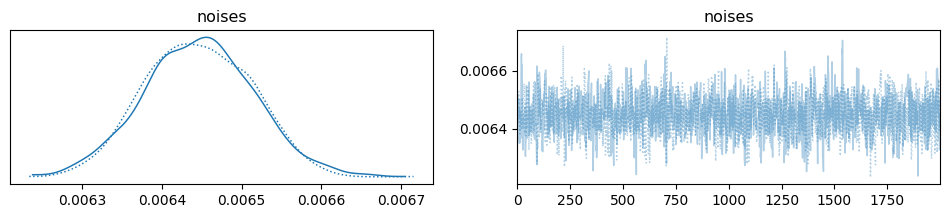

In [ ]:
pm.plot_trace(trace2_)

<Axes: title={'center': 'noises'}>

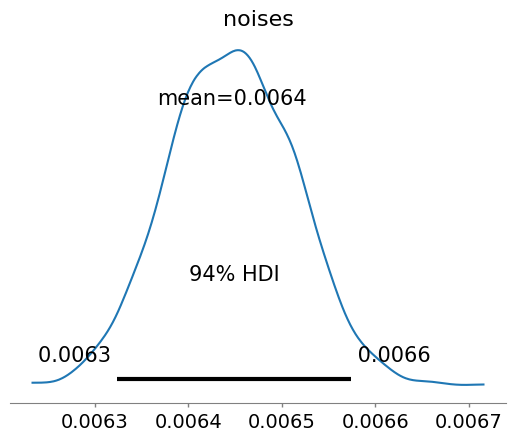

In [ ]:
pm.plot_posterior(trace2_)

In [ ]:
yo_pred2 = ppc2.posterior_predictive['yo_']          # (chain, draw, n_obs)
yo_pred_flat2 = yo_pred2.values.reshape(-1, yo_pred2.shape[-1])  # (chain*draw, n_obs)

N_SAMPLES_PLOT = 200  # jumlah garis merah tipis yang mau digambar
rng_plot2 = np.random.default_rng(0)
sample_idx2 = rng_plot2.choice(yo_pred_flat2.shape[0],
                              size=min(N_SAMPLES_PLOT, yo_pred_flat2.shape[0]),
                              replace=False)

Text(0.5, 1.0, 'Bayesian MCMC Porosity Log')

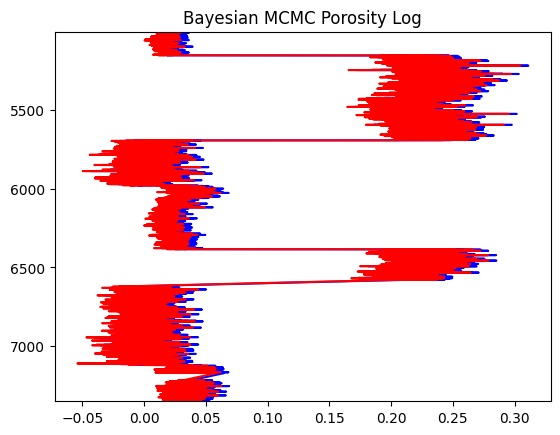

In [ ]:
# plt.subplot(121)
plt.plot(poros_noisy.flatten(), d, '-b')
# plt.title('porosity log')
# plt.subplot(122)
plt.plot(PHIE.flatten(), d, '-r')
plt.ylim([max(d), min(d)])
# plt.savefig("mcmc porosity widb1 0.5.jpg", format='jpg', dpi=300)
plt.title('Bayesian MCMC Porosity Log')

In [ ]:
pred_mean2 = yo_pred_flat2.mean(axis=0)
pred_std2 = yo_pred_flat2.std(axis=0)

print(f"\nRata-rata lebar sebaran (std posterior predictive): {pred_std2.mean():.4f}")
print(f"Rata-rata selisih |prediksi - asli|                : "
      f"{np.mean(np.abs(pred_mean2 - PHIE)):.4f}")


Rata-rata lebar sebaran (std posterior predictive): 0.0064
Rata-rata selisih |prediksi - asli|                : 0.0001


In [ ]:
PHIE = PHIE.flatten()
poros_noisy = poros_noisy.flatten()

<class 'numpy.float64'> 1.0


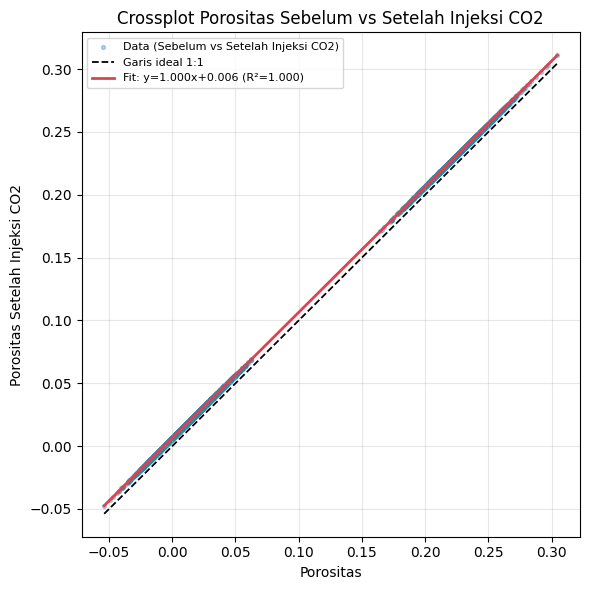

In [ ]:
result2 = stats.linregress(PHIE, poros_noisy)
slope2, intercept2, r_value2, p_value2, std_err2 = result2
r_squared2 = r_value2 ** 2

print(type(slope2), slope2)   # pastikan sekarang scalar, misal: <class 'numpy.float64'> 0.9987

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(PHIE, poros_noisy, s=8, alpha=0.35, color="#2E86AB",
           label="Data (Sebelum vs Setelah Injeksi CO2)")

x_line2 = np.linspace(PHIE.min(), PHIE.max(), 100)
ax.plot(x_line2, x_line2, "k--", lw=1.3, label="Garis ideal 1:1")
ax.plot(x_line2, slope2 * x_line2 + intercept2, color="#D64550", lw=2,
        label=f"Fit: y={slope2:.3f}x+{intercept2:.3f} (R²={r_squared2:.3f})")

ax.set_xlabel("Porositas")
ax.set_ylabel("Porositas Setelah Injeksi CO2")
ax.set_title("Crossplot Porositas Sebelum vs Setelah Injeksi CO2")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
diff = poros_noisy - PHIE             # selisih per titik (noisy - asli)
mean_val = (PHIE + poros_noisy) / 2    # rata-rata dari sepasang nilai per titik

bias = np.mean(diff)                 # rata-rata perbedaan keseluruhan
std_diff = np.std(diff)
loa_upper = bias + 1.96 * std_diff   # batas atas (limits of agreement 95%)
loa_lower = bias - 1.96 * std_diff   # batas bawah

rmse = np.sqrt(np.mean(diff ** 2))
mae = np.mean(np.abs(diff))

In [ ]:
before = pd.DataFrame({
    "DEPT": d,
    "Density": density2,
    "Vp": vp2,
})

print(before.shape)
before.head()

(4236, 3)


,DEPT,Density,Vp
DEPT,,,
5004.0,5004.0,2.4186,3055.639098
5004.5,5004.5,2.4710,3172.356370
5005.0,5005.0,2.4955,3251.546832
5005.5,5005.5,2.4011,3151.364764
5006.0,5006.0,2.4070,3086.269745


In [ ]:
after = pd.DataFrame({
    "DEPT": d,
    "Denafter": density2_noisy,
    "Vpafter": vp2_noisy,
    "porosafter": poros_noisy
})

print(after.shape)
after.head()

(4236, 4)


,DEPT,Denafter,Vpafter,porosafter
DEPT,,,,
5004.0,5004.0,2.398818,3055.654732,0.024814
5004.5,5004.5,2.463644,3172.355351,0.017088
5005.0,5005.0,2.521259,3251.547507,0.026872
5005.5,5005.5,2.404979,3151.342935,0.037908
5006.0,5006.0,2.425405,3086.298030,0.024214


In [ ]:
!pip install keras

In [ ]:
!pip install sklearn
import sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, InputLayer, MaxPooling1D

In [ ]:
DF = lasio.read("/content/synthetic_well_log_subset.las")
df = DF.df()
df

,RHOB,DT,SW
DEPT,,,
5000.0,2.4477,92.68,0.5224
5000.5,2.4534,100.01,0.4730
5001.0,NaN,96.34,0.5091
5001.5,NaN,96.52,0.6519
5002.0,NaN,93.25,0.5541
...,...,...,...
7347.5,2.5457,65.81,0.6111
7348.0,2.5648,67.67,0.6407
7348.5,2.5655,63.01,0.5782


In [ ]:
df = df.dropna()
df

,RHOB,DT,SW
DEPT,,,
5000.0,2.4477,92.68,0.5224
5000.5,2.4534,100.01,0.4730
5004.0,2.4186,99.75,0.6524
5004.5,2.4710,96.08,0.5109
5005.0,2.4955,93.74,0.6907
...,...,...,...
7347.5,2.5457,65.81,0.6111
7348.0,2.5648,67.67,0.6407
7348.5,2.5655,63.01,0.5782


In [ ]:
density_train = df['RHOB'].to_numpy()
dt_train = df['DT'].to_numpy()
sw_train = df['SW'].to_numpy()
vp_train = 0.3048 / (dt_train * 1e-6)

In [ ]:
dentrain = density_train.astype(np.float32)
vp_train = vp_train.astype(np.float32)
swtrain = sw_train.astype(np.float32)/100
density_test = density2.astype(np.float32)
vp_test = vp2.astype(np.float32)

In [ ]:
dentrain = np.asarray(dentrain)
vp_train = np.asarray(vp_train)
swtrain = np.asarray(swtrain)
density_test = np.asarray(density_test)
vp_test = np.asarray(vp_test)

In [ ]:
X = np.column_stack([dentrain, dt_train, vp_train])
y = sw_train.reshape(-1, 1)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)

n_features = X_train_scaled.shape[1]
X_train_scaled = X_train_scaled.reshape(-1, n_features, 1)
X_val_scaled = X_val_scaled.reshape(-1, n_features, 1)

In [ ]:
model = Sequential([
    InputLayer(input_shape=(n_features, 1)),
    Conv1D(32, kernel_size=2, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2, padding='same'),
    Conv1D(16, kernel_size=2, activation='relu', padding='same'),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)  # Output: SW
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 3, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 2, 16)          │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,225 (8.69 KB)

 Trainable params: 2,225 (8.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train_scaled, y_train_scaled, validation_data=(X_test_scaled, y_test_scaled),
    epochs=20, batch_size=32, verbose=1)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0415 - val_loss: 0.0375
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0267 - val_loss: 0.0336
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0205 - val_loss: 0.0457
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0189 - val_loss: 0.0580
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 - val_loss: 0.0628
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0186 - val_loss: 0.0681
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0181 - val_loss: 0.0738
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0185 - val_loss: 0.0722
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0179 - val_loss: 0.0796
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0180 - val_loss: 0.0822
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0181 - val_loss: 0.0850
Epoch 12/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

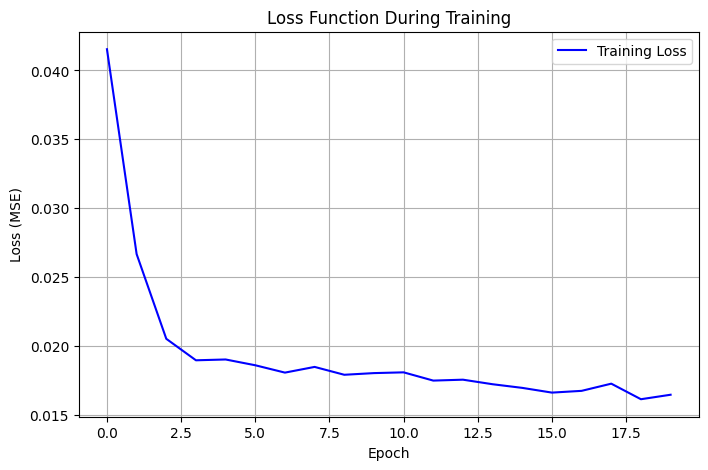

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title('Loss Function During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()
# plt.savefig("Loss Function.jpg", format='jpg', dpi=300)

In [ ]:
X_target = np.column_stack([density2, DT, vp2])
X_target_scaled = scaler_X.transform(X_target).reshape(-1, n_features, 1)

In [ ]:
sw_pred_clean = scaler_y.inverse_transform(
    model.predict(X_target_scaled)
).flatten()

133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
rng = np.random.default_rng(123)
noise_rhob = 0.02
noise_dt = 0.02

rhob_t_noisy = density2 + rng.normal(0, noise_rhob, size=len(density2))
dt_t_noisy = DT + rng.normal(0, noise_dt, size=len(DT))
vp_t_noisy = 0.3048 / (dt_t_noisy * 1e-6)

X_target_noisy = np.column_stack([rhob_t_noisy, dt_t_noisy, vp_t_noisy])
X_target_noisy_scaled = scaler_X.transform(X_target_noisy).reshape(-1, n_features, 1)

sw_pred_noisy = scaler_y.inverse_transform(
    model.predict(X_target_noisy_scaled)
).flatten()

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
diff = sw_pred_noisy - sw_pred_clean
bias = np.mean(diff)
std_diff = np.std(diff)
rmse = np.sqrt(np.mean(diff ** 2))

In [ ]:
coba = pd.DataFrame({
    "DEPT": d,
    "before": sw_pred_noisy,
    "after": sw_pred_clean,
})

print(after.shape)
coba.head()

(4236, 5)


,DEPT,before,after
DEPT,,,
5004.0,5004.0,0.508371,0.516945
5004.5,5004.5,0.515635,0.522818
5005.0,5005.0,0.579028,0.553867
5005.5,5005.5,0.480326,0.478839
5006.0,5006.0,0.510338,0.501933


Text(0.5, 1.0, 'CNN Saturation Water Log')

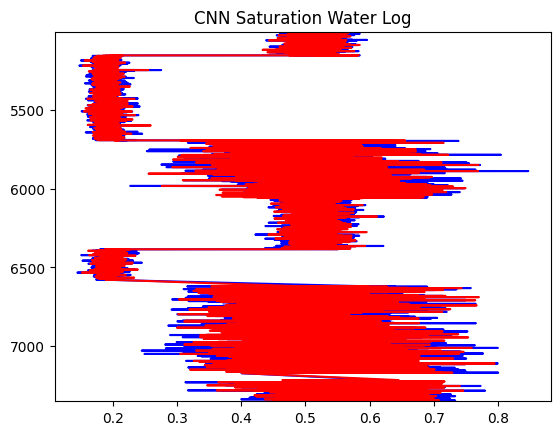

In [ ]:
# plt.subplot(121)
plt.plot(sw_pred_noisy, d, '-b')
# plt.title('porosity log')
# plt.subplot(122)
plt.plot(sw_pred_clean, d, '-r')
plt.ylim([max(d), min(d)])
# plt.savefig("mcmc porosity widb1 0.5.jpg", format='jpg', dpi=300)
plt.title('CNN Saturation Water Log')

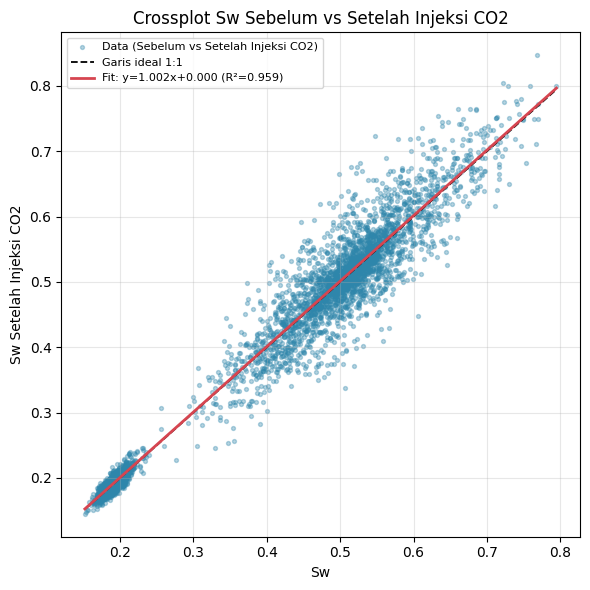

In [ ]:
result3 = stats.linregress(sw_pred_clean, sw_pred_noisy)
slope3, intercept3, r_value3, p_value3, std_err3 = result3
r_squared3 = r_value3 ** 2

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sw_pred_clean, sw_pred_noisy, s=8, alpha=0.35, color="#2E86AB",
           label="Data (Sebelum vs Setelah Injeksi CO2)")

x_line3 = np.linspace(sw_pred_clean.min(), sw_pred_clean.max(), 100)
ax.plot(x_line3, x_line3, "k--", lw=1.3, label="Garis ideal 1:1")
ax.plot(x_line3, slope3 * x_line3 + intercept3, color="#D64550", lw=2,
        label=f"Fit: y={slope3:.3f}x+{intercept3:.3f} (R²={r_squared3:.3f})")

ax.set_xlabel("Sw")
ax.set_ylabel("Sw Setelah Injeksi CO2")
ax.set_title("Crossplot Sw Sebelum vs Setelah Injeksi CO2")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()